In [1]:
!pip install -q transformers datasets pillow matplotlib seaborn wordcloud

In [2]:
import os
import re
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
import torch
from transformers import pipeline, CLIPProcessor, CLIPModel, BlipProcessor, BlipForConditionalGeneration

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"serhiimelnykkk","key":"1a4e5de8629f669eaeb0195336bf3967"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c gen-ai-competition
!unzip -q gen-ai-competition.zip -d data

100% 15.7M/15.7M [00:02<00:00, 7.79MB/s]



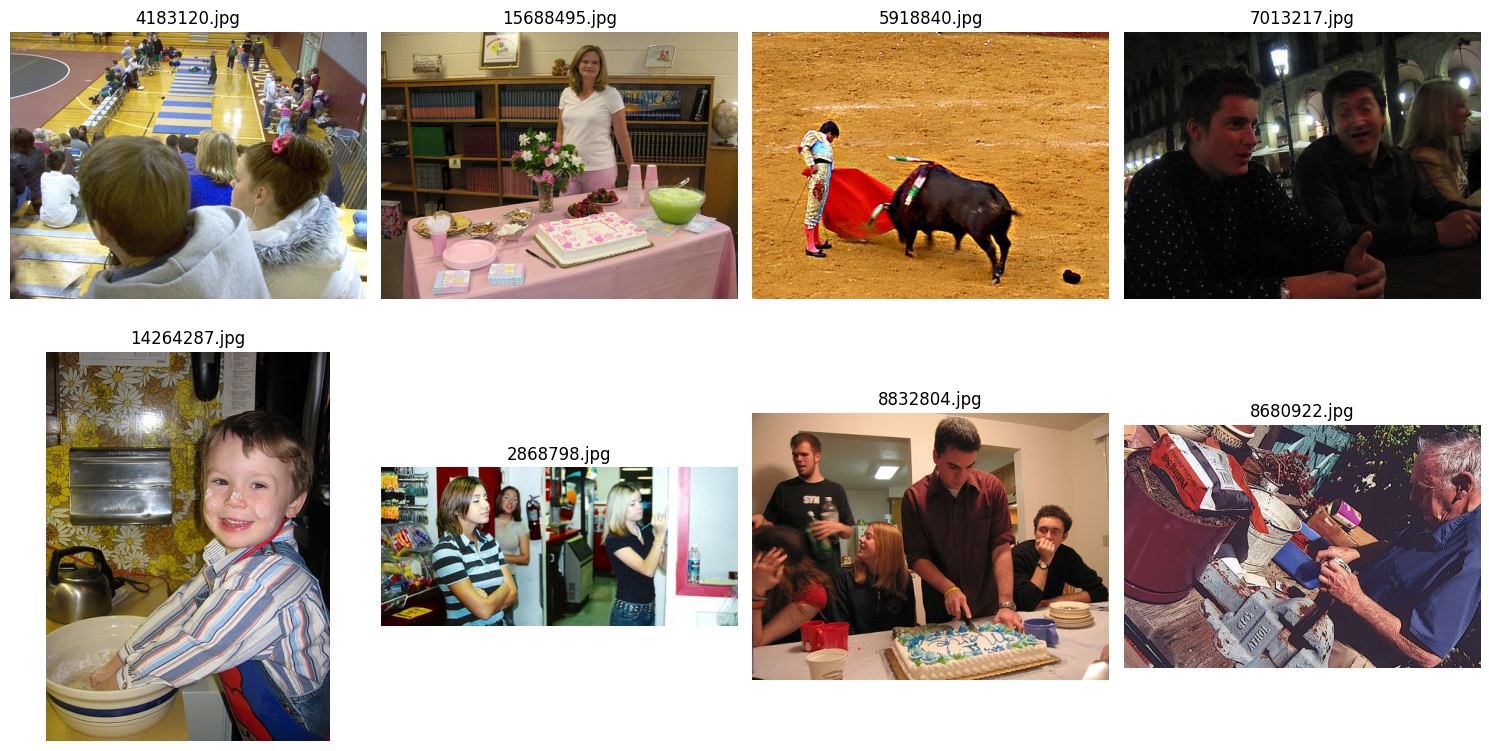

In [5]:
test_dir = "data/data"

plt.figure(figsize=(15, 8))

image_files = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png', '.jpeg'))][:8]

for i, img_file in enumerate(image_files):
    img_path = os.path.join(test_dir, img_file)
    img = Image.open(img_path)

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(img_file)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16
).to("cuda")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

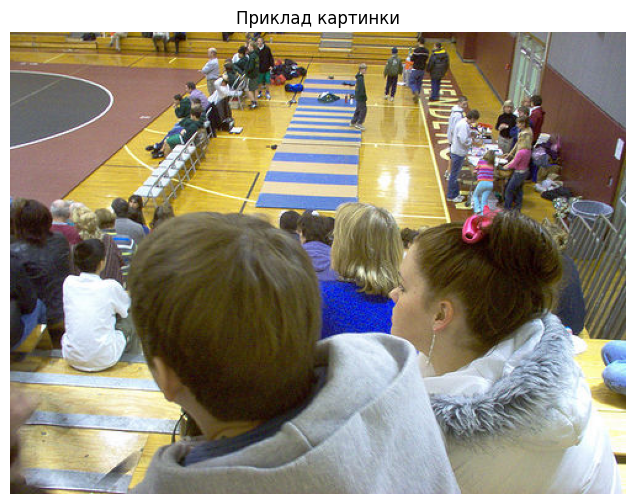

Згенерований опис:
a photo of two people sitting on the bleachers watching a wrestling match in a gymnasium



In [36]:
test_dir = "data/data"

image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
test_image_path = os.path.join(test_dir, image_files[0])

img = Image.open(test_image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Приклад картинки")
plt.axis('off')
plt.show()

prompt = "a photo of"
inputs = processor(images=img, text=prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        num_beams=8,
        min_new_tokens=15,
        max_new_tokens=60,
        length_penalty=1.3,
        repetition_penalty=1.2,
        early_stopping=True
    )

caption = processor.decode(outputs[0], skip_special_tokens=True)
print("Згенерований опис:")
print(caption)

In [38]:
results = []

for i, img_file in enumerate(tqdm(image_files[:10])):
    img_path = os.path.join(test_dir, img_file)
    img = Image.open(img_path).convert("RGB")
    img = img.resize((384, 384))

    prompt = "a photo of"
    inputs = processor(images=img, text=prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            num_beams=8,
            min_new_tokens=15,
            max_new_tokens=60,
            length_penalty=1.3,
            repetition_penalty=1.2,
            early_stopping=True
        )

    caption = processor.decode(outputs[0], skip_special_tokens=True)

    results.append({
        'image': img_file,
        'caption': caption
    })

df_test = pd.DataFrame(results)
display(df_test)

100%|██████████| 10/10 [00:07<00:00,  1.33it/s]


,image,caption
0,4183120.jpg,a photo of two people sitting on bleachers wat...
1,15688495.jpg,a photo of a woman standing in front of a tabl...
2,5918840.jpg,a photo of a man in a bull ring with a red cap...
3,7013217.jpg,a photo of a group of people sitting at a tabl...
4,14264287.jpg,a photo of a young boy in a kitchen with a bow...
5,2868798.jpg,a photo of a woman standing in front of a coun...
6,8832804.jpg,a photo of a man cutting a cake in front of a ...
7,8680922.jpg,a photo of an old man working on a piece of me...
8,3753939.jpg,a photo of an airplane on the tarmac with a ma...
9,14107151.jpg,a photo of a man and a woman sleeping on a sub...


In [39]:
image_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
image_files.sort()

captions_dict = {}

for img_file in tqdm(image_files):
    img_path = os.path.join(test_dir, img_file)
    img = Image.open(img_path).convert("RGB")

    prompt = "a photo of"
    inputs = processor(images=img, text=prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            num_beams=8,
            min_new_tokens=15,
            max_new_tokens=60,
            length_penalty=1.3,
            repetition_penalty=1.2,
            early_stopping=True
        )

    caption = processor.decode(outputs[0], skip_special_tokens=True)
    captions_dict[img_file] = caption

100%|██████████| 300/300 [03:46<00:00,  1.33it/s]


In [40]:
df_captions = pd.DataFrame({
    'image': list(captions_dict.keys()),
    'caption': list(captions_dict.values())
})

display(df_captions.head(15))

df_captions.to_csv("captions_blip.csv", index=False)

,image,caption
0,10002456.jpg,a photo of a group of men working on a constru...
1,10010052.jpg,a photo of a woman on roller skates talking on...
2,10082347.jpg,a photo of a young man holding a tennis racque...
3,10082348.jpg,a photo of a man standing in front of two urin...
4,10090841.jpg,a photo of a man sitting at a table with a gla...
5,10101477.jpg,a photo of a man holding a broom in front of a...
6,10160966.jpg,a photo of a man sitting on the ground with a ...
7,10188041.jpg,a photo of a man standing in front of a large ...
8,10287332.jpg,a photo of three men working on the roof of a ...
9,10350842.jpg,a photo of a man paddling a canoe on the water...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [31]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to("cuda" if torch.cuda.is_available() else "cpu")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
submission_rows = []
embedding_dim = 512

for img_file in tqdm(captions_dict.keys()):
    base_name = os.path.splitext(img_file)[0]
    caption = captions_dict[img_file]

    inputs = clip_processor(
        text=caption,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(clip_model.device)

    with torch.no_grad():
        text_features = clip_model.text_model(**inputs).pooler_output
        text_features = clip_model.text_projection(text_features)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        embedding = text_features.squeeze().cpu().numpy()

    for dim in range(embedding_dim):
        embedding_id = f"{base_name}_{dim}"
        submission_rows.append({
            "Embedding_id": embedding_id,
            "Embedding_value": float(embedding[dim])
        })

final_submission = pd.DataFrame(submission_rows)
final_submission.to_csv("submission.csv", index=False)

display(final_submission.head(10))

100%|██████████| 300/300 [00:02<00:00, 103.27it/s]


,Embedding_id,Embedding_value
0,10002456_0,-0.013825
1,10002456_1,0.026877
2,10002456_2,-0.052021
3,10002456_3,0.018515
4,10002456_4,-0.077138
5,10002456_5,0.036891
6,10002456_6,-0.001513
7,10002456_7,0.031591
8,10002456_8,-0.019800
9,10002456_9,0.071765


In [42]:
!kaggle competitions submit -c gen-ai-competition -f submission.csv -m "First submission - BLIP + CLIP baseline"

100% 4.85M/4.85M [00:02<00:00, 1.81MB/s]
Successfully submitted to GenAI competition

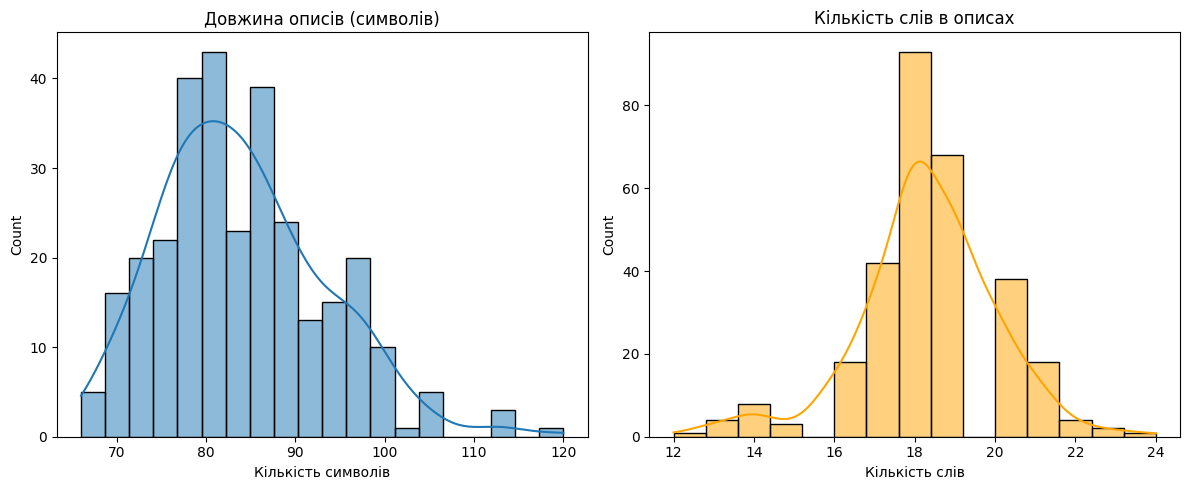

In [43]:
df_captions['caption_length'] = df_captions['caption'].apply(len)
df_captions['word_count'] = df_captions['caption'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_captions['caption_length'], bins=20, kde=True)
plt.title('Довжина описів (символів)')
plt.xlabel('Кількість символів')

plt.subplot(1, 2, 2)
sns.histplot(df_captions['word_count'], bins=15, kde=True, color='orange')
plt.title('Кількість слів в описах')
plt.xlabel('Кількість слів')

plt.tight_layout()
plt.show()

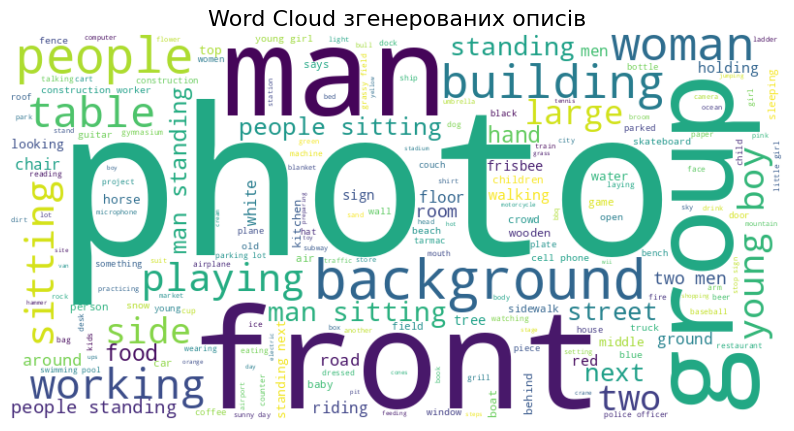

In [44]:
all_text = " ".join(df_captions['caption'])

plt.figure(figsize=(10, 6))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud згенерованих описів', fontsize=16)
plt.show()

In [27]:
display(df_captions[['image', 'caption']].sample(8).reset_index(drop=True))

,image,caption
0,11214370.jpg,a man working on a sidewalk\n
1,3367399.jpg,a man standing at a gas station\n
2,7300628.jpg,a group of people standing in a grassy area\n
3,1254659.jpg,a neon sign that says mongolian bbq\n
4,15308698.jpg,two people walking on top of a sand dune\n
5,12243003.jpg,a group of people sitting on a bench\n
6,11338041.jpg,a group of people standing in front of a build...
7,15641879.jpg,a man in a store\n
